# Buscador Avanzado de Sentimientos USM

Este notebook utiliza el motor de búsqueda de Reddit para encontrar menciones históricas de la **USM** y la **UTFSM** en subreddits chilenos, con soporte para `pysentimiento`.

---

In [3]:
# 1. Instalación y Configuración
!pip install aiohttp aiofiles pandas matplotlib seaborn wordcloud scikit-learn nest_asyncio pysentimiento -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import sys
import asyncio
import nest_asyncio
import aiohttp

nest_asyncio.apply()
project_root = os.path.abspath("../src")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from analytics.sentiment import analyze_sentiment, analyze_sentiment_advanced, STOPWORDS

print("Buscador listo con soporte para Pysentimiento!")

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Python312\Scripts\pip.exe\__main__.py", line 4, in <module>
ModuleNotFoundError: No module named 'pip'


ModuleNotFoundError: No module named 'pandas'

## 1. Función de Búsqueda Profunda
Usaremos el endpoint de búsqueda de Reddit para encontrar menciones específicas.

In [ ]:
async def deep_search_reddit(query, subreddits, limit=100):
    results = []
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    
    async with aiohttp.ClientSession(headers=headers) as session:
        for sub in subreddits:
            print(f"Buscando '{query}' en r/{sub}...")
            url = f"https://www.reddit.com/r/{sub}/search.json?q={query}&limit={limit}&restrict_sr=1&sort=relevance&t=all"
            
            try:
                async with session.get(url) as response:
                    if response.status == 200:
                        data = await response.json()
                        posts = data.get('data', {}).get('children', [])
                        for p in posts:
                            res = p['data']
                            results.append({
                                'title': res.get('title'),
                                'text': res.get('selftext', ''),
                                'score': res.get('score'),
                                'subreddit': sub,
                                'permalink': res.get('permalink'),
                                'created_utc': res.get('created_utc')
                            })
                        print(f"   Encontrados {len(posts)} posts.")
                    else:
                        print(f"Error {response.status} en r/{sub}")
            except Exception as e:
                print(f"Error: {e}")
            await asyncio.sleep(1)
    return pd.DataFrame(results)

print("✅ Función de búsqueda configurada.")

✅ Función de búsqueda configurada.


## 2. Ejecutar Búsqueda Masiva
Buscamos por múltiples términos en varios subreddits.

In [ ]:
SUBS = ["chile", "EducacionChile", "valparaiso", "Santiago", "universidadeschile"]
TERMINOS = ["USM", "UTFSM", "Santa Maria", "Sansano", "Sansana"]

all_dfs = []
for term in TERMINOS:
    df_term = await deep_search_reddit(term, SUBS, limit=100)
    all_dfs.append(df_term)

if all_dfs:
    df_final = pd.concat(all_dfs, ignore_index=True).drop_duplicates(subset=['permalink'])
    print(f"\nTotal de posts únicos sobre la USM encontrados: {len(df_final)}")
else:
    print("No se encontraron resultados.")
    df_final = pd.DataFrame()

df_final.head()

🔍 Buscando 'USM' en r/chile...
   Encontrados 94 posts.
🔍 Buscando 'USM' en r/EducacionChile...
   Encontrados 100 posts.
🔍 Buscando 'USM' en r/valparaiso...
   Encontrados 0 posts.
🔍 Buscando 'USM' en r/Santiago...
   Encontrados 3 posts.
🔍 Buscando 'USM' en r/universidadeschile...
   Encontrados 0 posts.
🔍 Buscando 'UTFSM' en r/chile...
   Encontrados 28 posts.
🔍 Buscando 'UTFSM' en r/EducacionChile...
   Encontrados 52 posts.
🔍 Buscando 'UTFSM' en r/valparaiso...
   Encontrados 0 posts.
🔍 Buscando 'UTFSM' en r/Santiago...
   Encontrados 1 posts.
🔍 Buscando 'UTFSM' en r/universidadeschile...
   Encontrados 0 posts.
🔍 Buscando 'Santa Maria' en r/chile...
   Encontrados 30 posts.
🔍 Buscando 'Santa Maria' en r/EducacionChile...
   Encontrados 43 posts.
🔍 Buscando 'Santa Maria' en r/valparaiso...
   Encontrados 0 posts.
🔍 Buscando 'Santa Maria' en r/Santiago...
   Encontrados 3 posts.
🔍 Buscando 'Santa Maria' en r/universidadeschile...
   Encontrados 0 posts.
🔍 Buscando 'Sansano' en r/ch

,title,text,score,subreddit,permalink,created_utc
0,El gran mito de la USM,https://preview.redd.it/qz5t0ycx840h1.png?widt...,214,chile,/r/chile/comments/1t85hg7/el_gran_mito_de_la_usm/,1.778334e+09
1,Estudiante ataca a profesor en USM de Valparaí...,,181,chile,/r/chile/comments/1p7lmc3/estudiante_ataca_a_p...,1.764196e+09
2,Amenaza de tiroteo en campus de la usm,,605,chile,/r/chile/comments/u6j0w1/amenaza_de_tiroteo_en...,1.650304e+09
3,Me eché 4 ramos en la USM y quedé eliminado. ¿...,Estoy estudiando un Técnico Universitario en E...,109,chile,/r/chile/comments/1e5cwz3/me_eché_4_ramos_en_l...,1.721204e+09
4,Experiencias y opiniones de la USM?,Contexto: estoy en 4to medio\n\nQuiero estudia...,52,chile,/r/chile/comments/15l515l/experiencias_y_opini...,1.691462e+09


## 3. Análisis de Sentimientos (Pysentimiento)
Procesamos los datos con `pysentimiento` para captar el contexto chileno.

🧠 Analizando con Pysentimiento (esto puede tardar la primera vez)... 


C:\Users\byron\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\byron\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\byron\.cache\huggingface\hub\models--pysentimiento--robertuito-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingf

📊 Resumen de Sentimientos:
sentiment_label
neutral     249
negative     93
positive     12
Name: count, dtype: int64


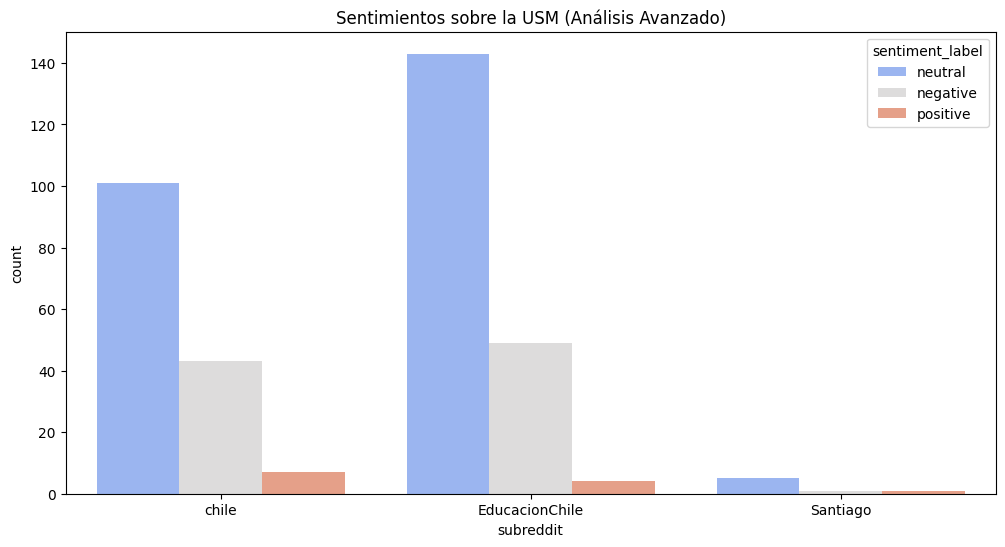

In [ ]:
if not df_final.empty:
    print("Analizando con Pysentimiento (esto puede tardar la primera vez)... ")
    df_final['full_content'] = df_final['title'].fillna('') + " " + df_final['text'].fillna('')
    
    # Usamos la versión avanzada que integra pysentimiento
    res_sentiment = df_final['full_content'].apply(analyze_sentiment_advanced)
    df_final['sentiment_score'] = [r[0] for r in res_sentiment]
    df_final['sentiment_label'] = [r[1] for r in res_sentiment]

    print("Resumen de Sentimientos:")
    print(df_final['sentiment_label'].value_counts())

    # Gráfico de distribución
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_final, x='subreddit', hue='sentiment_label', palette='coolwarm')
    plt.title('Sentimientos sobre la USM (Análisis Avanzado)')
    plt.show()

## 4. Nube de Palabras de la USM
Visualización de conceptos filtrando conectores informales.

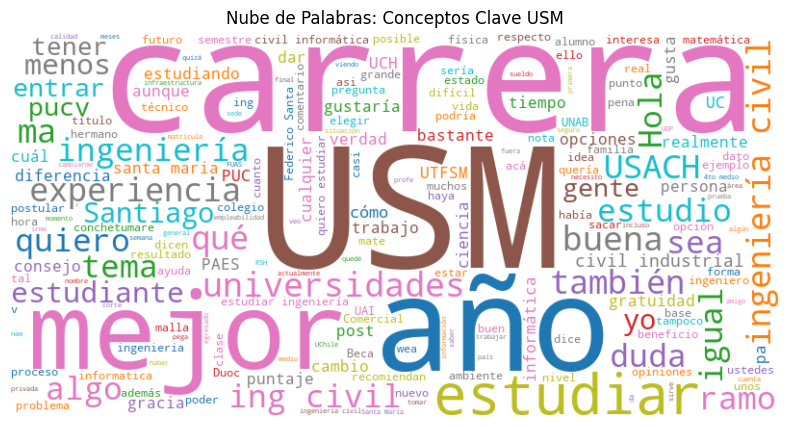

In [5]:
if not df_final.empty:
    texto_completo = " ".join(df_final['full_content'])
    if texto_completo.strip():
        wc = WordCloud(
            width=800, 
            height=400, 
            background_color='white', 
            colormap='tab10', 
            stopwords=STOPWORDS
        ).generate(texto_completo)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Nube de Palabras: Conceptos Clave USM')
        plt.show()

## 5. Exportar para Entrenamiento
Generamos el CSV final listo para entrenar modelos.

In [ ]:
if not df_final.empty:
    os.makedirs("data/usm_final", exist_ok=True)
    df_final[['full_content', 'sentiment_label']].to_csv("data/usm_final/datos_entrenamiento_usm.csv", index=False)
    print("Archivo generado con éxito en: data/usm_final/datos_entrenamiento_usm.csv")

✅ Archivo generado con éxito en: data/usm_final/datos_entrenamiento_usm.csv
